In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, json, hashlib
from pathlib import Path
from collections import Counter
from datasets import load_from_disk
import wandb

# ── Config ──────────────────────────────────────────────
PROJECT_ROOT = Path("..") 
DATA_RAW     = PROJECT_ROOT / "data" / "raw"
DATA_PROC    = PROJECT_ROOT / "data" / "processed"
DATA_PROC.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 12
sns.set_style("whitegrid")

# Init W&B — all EDA charts will be logged here
wandb.init(
    project="bangla-fake-news-detector",
    entity="mdmasumkhan-personal",
    name="01-eda-imbalance",
    tags=["eda", "data-analysis"],
    config={"notebook": "01_eda_and_imbalance"},
    )
print("W&B run:", wandb.run.url)

W&B run: https://wandb.ai/mdmasumkhan-personal/bangla-fake-news-detector/runs/oy4elx0j


In [7]:
# ── Find the CSV files ───────────────────────────────────
banfake_dir = DATA_RAW / "banfakenews"
csv_files = list(banfake_dir.glob("*.csv"))
print("Files found:", [f.name for f in csv_files])

# Load all CSVs and concatenate
dfs = []
for f in csv_files:
    df_tmp = pd.read_csv(f)
    df_tmp["source_file"] = f.name
    dfs.append(df_tmp)
    print(f"{f.name}: {len(df_tmp)} rows, columns: {list(df_tmp.columns)}")

df_raw = pd.concat(dfs, ignore_index=True)
print(f"\nTotal rows: {len(df_raw)}")
print(f"\nColumn dtypes:\n{df_raw.dtypes}")
print(f"\nFirst row:\n{df_raw.iloc[0]}")

Files found: ['LabeledAuthentic-7K.csv', 'LabeledFake-1K.csv', 'Fake-1K.csv', 'Authentic-48K.csv']
LabeledAuthentic-7K.csv: 7202 rows, columns: ['articleID', 'domain', 'date', 'category', 'source', 'relation', 'headline', 'content', 'label', 'source_file']
LabeledFake-1K.csv: 1299 rows, columns: ['articleID', 'domain', 'date', 'category', 'source', 'relation', 'headline', 'content', 'label', 'F-type', 'source_file']
Fake-1K.csv: 1299 rows, columns: ['articleID', 'domain', 'date', 'category', 'headline', 'content', 'label', 'source_file']
Authentic-48K.csv: 48678 rows, columns: ['articleID', 'domain', 'date', 'category', 'headline', 'content', 'label', 'source_file']

Total rows: 58478

Column dtypes:
articleID        int64
domain          object
date            object
category        object
source          object
relation        object
headline        object
content         object
label          float64
source_file     object
F-type          object
dtype: object

First row:
articleID  

In [8]:
# Print actual column names so we can map them correctly
print("Columns:", df_raw.columns.tolist())
print("\nLabel column unique values:")

# BanFakeNews uses 'label' column with values like 'Fake', 'Authentic'
# Find the label column
label_col = None
for col in df_raw.columns:
    if df_raw[col].dtype == object:
        vals = df_raw[col].dropna().unique()
        if len(vals) < 10:
            print(f"  {col}: {vals}")
            if any(v.lower() in ['fake','authentic','real','satire'] 
                   for v in vals if isinstance(v, str)):
                label_col = col

print(f"\nDetected label column: '{label_col}'")

# Standardize
df = df_raw.copy()
df.columns = [c.lower().strip() for c in df.columns]
print("\nStandardized columns:", df.columns.tolist())

Columns: ['articleID', 'domain', 'date', 'category', 'source', 'relation', 'headline', 'content', 'label', 'source_file', 'F-type']

Label column unique values:
  relation: ['Related' 'Unrelated' 'related']
  source_file: ['LabeledAuthentic-7K.csv' 'LabeledFake-1K.csv' 'Fake-1K.csv'
 'Authentic-48K.csv']
  F-type: ['Satire' 'Clickbaits' 'Fake']

Detected label column: 'F-type'

Standardized columns: ['articleid', 'domain', 'date', 'category', 'source', 'relation', 'headline', 'content', 'label', 'source_file', 'f-type']


Raw label distribution:
label
1.0    55880
0.0     2598
Name: count, dtype: int64

Imbalance ratio: 21.5:1


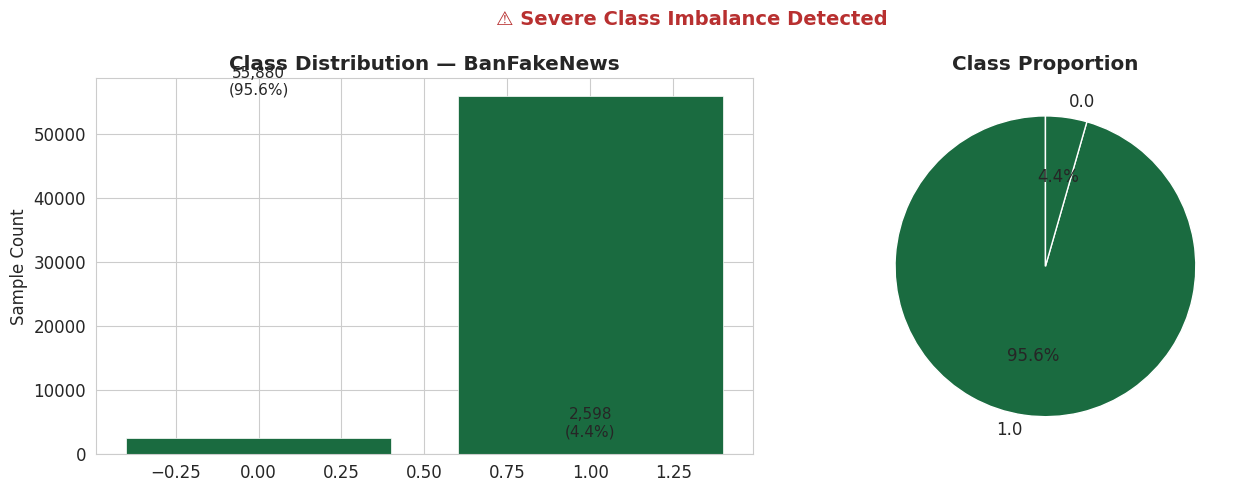


⚠ A naive majority-class classifier would achieve 95.6% accuracy with 0% fake recall!


In [10]:
label_col = "label"   # adjust if different from above

# Raw value counts
label_counts = df[label_col].value_counts()
print("Raw label distribution:")
print(label_counts)
print(f"\nImbalance ratio: {label_counts.max()/label_counts.min():.1f}:1")

# ── Plot ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ["#b83030" if "fake" in str(l).lower() else "#1a6b40" 
          for l in label_counts.index]
axes[0].bar(label_counts.index, label_counts.values, color=colors, 
            edgecolor="white", linewidth=0.5)
axes[0].set_title("Class Distribution — BanFakeNews", fontweight="bold")
axes[0].set_ylabel("Sample Count")
for i, (k, v) in enumerate(label_counts.items()):
    axes[0].text(i, v + 200, f"{v:,}\n({v/len(df)*100:.1f}%)", 
                 ha="center", fontsize=11)

# Pie chart
axes[1].pie(label_counts.values, labels=label_counts.index, 
            autopct="%1.1f%%", colors=colors, startangle=90)
axes[1].set_title("Class Proportion", fontweight="bold")

plt.suptitle("⚠ Severe Class Imbalance Detected", 
             color="#b83030", fontsize=14, fontweight="bold")
plt.tight_layout()

# Log to W&B
wandb.log({"class_distribution": wandb.Image(fig)})
wandb.log({f"n_{str(k).lower()}": v for k, v in label_counts.items()})
wandb.log({"imbalance_ratio": label_counts.max()/label_counts.min()})

plt.show()
print("\n⚠ A naive majority-class classifier would achieve",
      f"{label_counts.max()/len(df)*100:.1f}% accuracy with 0% fake recall!")

In [11]:
# Find the text column
text_col = None
for col in df.columns:
    if df[col].dtype == object and col not in [label_col, "source_file"]:
        avg_len = df[col].dropna().str.len().mean()
        if avg_len > 50:   # likely a text column
            print(f"Candidate text column: '{col}' — avg {avg_len:.0f} chars")
            text_col = col

print(f"\nUsing text column: '{text_col}'")

# Approximate token count (Bangla: ~2.5 chars per token on average)
df["char_len"]   = df[text_col].fillna("").str.len()
df["approx_tok"] = (df["char_len"] / 2.5).astype(int)

print(f"\nText length stats:")
print(df[["char_len","approx_tok"]].describe().round(0))

exceeds_512 = (df["approx_tok"] > 512).sum()
pct = exceeds_512 / len(df) * 100
print(f"\n⚠ Articles exceeding 512 tokens (approx): {exceeds_512:,} ({pct:.1f}%)")

Candidate text column: 'content' — avg 1796 chars

Using text column: 'content'

Text length stats:
       char_len  approx_tok
count   58478.0     58478.0
mean     1796.0       718.0
std      1480.0       592.0
min         3.0         1.0
25%       930.0       372.0
50%      1383.0       553.0
75%      2124.0       849.0
max     27155.0     10862.0

⚠ Articles exceeding 512 tokens (approx): 32,036 (54.8%)


/tmp/ipykernel_78679/2724889928.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_by_class, labels=classes, patch_artist=True,


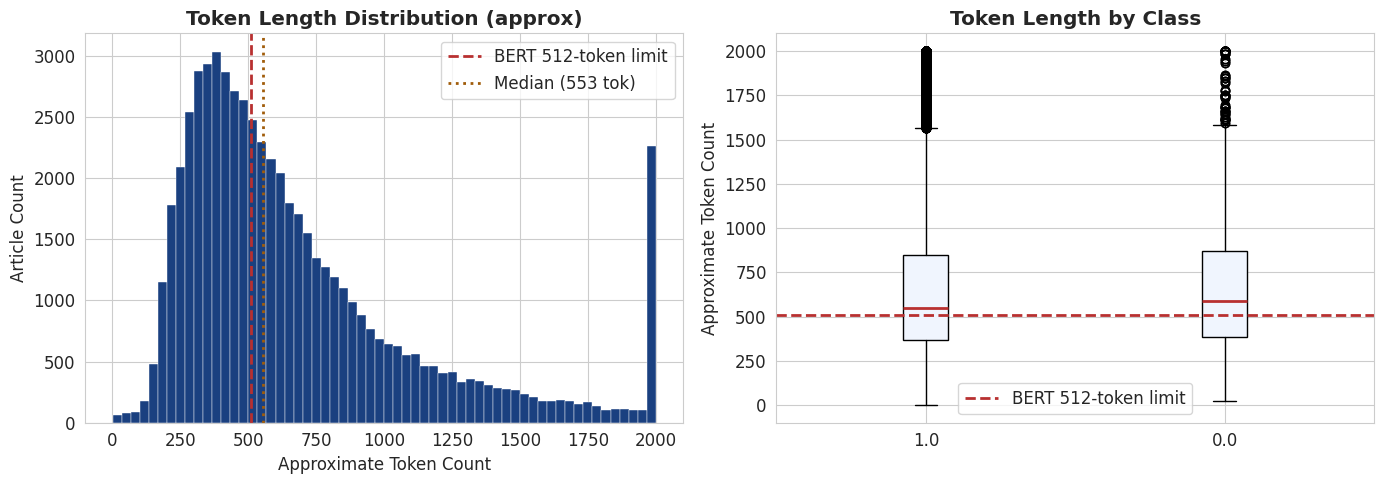

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of token counts
axes[0].hist(df["approx_tok"].clip(0, 2000), bins=60, 
             color="#1a4080", edgecolor="white", linewidth=0.3)
axes[0].axvline(512, color="#b83030", linewidth=2, 
                linestyle="--", label="BERT 512-token limit")
axes[0].axvline(df["approx_tok"].median(), color="#a05c0a", 
                linewidth=2, linestyle=":", label=f"Median ({df['approx_tok'].median():.0f} tok)")
axes[0].set_title("Token Length Distribution (approx)", fontweight="bold")
axes[0].set_xlabel("Approximate Token Count")
axes[0].set_ylabel("Article Count")
axes[0].legend()

# Boxplot by class
df_plot = df[[label_col, "approx_tok"]].copy()
classes = df_plot[label_col].unique()
data_by_class = [df_plot[df_plot[label_col]==c]["approx_tok"].clip(0,2000) 
                 for c in classes]
axes[1].boxplot(data_by_class, labels=classes, patch_artist=True,
                boxprops=dict(facecolor="#f0f5fe"),
                medianprops=dict(color="#b83030", linewidth=2))
axes[1].axhline(512, color="#b83030", linewidth=2, linestyle="--", 
                label="BERT 512-token limit")
axes[1].set_title("Token Length by Class", fontweight="bold")
axes[1].set_ylabel("Approximate Token Count")
axes[1].legend()

plt.tight_layout()
wandb.log({"token_length_distribution": wandb.Image(fig)})
plt.show()

In [13]:
def text_hash(text):
    if not isinstance(text, str):
        return None
    return hashlib.sha256(text.strip().lower().encode()).hexdigest()

df["text_hash"] = df[text_col].apply(text_hash)

total       = len(df)
n_dupes     = df["text_hash"].duplicated().sum()
n_null_text = df[text_col].isna().sum()

print(f"Total rows:          {total:,}")
print(f"Null/empty text:     {n_null_text:,} ({n_null_text/total*100:.2f}%)")
print(f"Duplicate texts:     {n_dupes:,} ({n_dupes/total*100:.2f}%)")
print(f"Clean unique rows:   {total - n_dupes - n_null_text:,}")

wandb.log({
    "total_rows": total,
    "duplicate_texts": n_dupes,
    "null_texts": n_null_text,
    "pct_exceeds_512_tokens": pct
})

Total rows:          58,478
Null/empty text:     0 (0.00%)
Duplicate texts:     6,481 (11.08%)
Clean unique rows:   51,997


In [14]:
from sklearn.metrics import classification_report

majority_class = df[label_col].mode()[0]
y_true = df[label_col]
y_pred = [majority_class] * len(y_true)

print(f"Majority class (always predict): '{majority_class}'")
print("\nMajority classifier performance:")
print(classification_report(y_true, y_pred, zero_division=0))
print("─" * 60)
print("⚠ This is the DANGER BASELINE.")
print("  Our model must dramatically beat this — especially on Fake recall.")

Majority class (always predict): '1.0'

Majority classifier performance:
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00      2598
         1.0       0.96      1.00      0.98     55880

    accuracy                           0.96     58478
   macro avg       0.48      0.50      0.49     58478
weighted avg       0.91      0.96      0.93     58478

────────────────────────────────────────────────────────────
⚠ This is the DANGER BASELINE.
  Our model must dramatically beat this — especially on Fake recall.


In [15]:
# Save a clean summary JSON for the preprocessing step
summary = {
    "total_rows":       int(total),
    "label_col":        label_col,
    "text_col":         text_col,
    "label_counts":     {str(k): int(v) for k, v in label_counts.items()},
    "imbalance_ratio":  float(round(label_counts.max()/label_counts.min(), 2)),
    "pct_over_512_tok": float(round(pct, 2)),
    "n_duplicates":     int(n_dupes),
    "n_null_text":      int(n_null_text),
    "majority_class":   majority_class
}

with open(DATA_PROC / "eda_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Saved:", DATA_PROC / "eda_summary.json")
print(json.dumps(summary, indent=2))

wandb.log(summary)
wandb.finish()
print("\n✓ EDA complete. W&B run closed.")

Saved: ../data/processed/eda_summary.json
{
  "total_rows": 58478,
  "label_col": "label",
  "text_col": "content",
  "label_counts": {
    "1.0": 55880,
    "0.0": 2598
  },
  "imbalance_ratio": 21.51,
  "pct_over_512_tok": 54.78,
  "n_duplicates": 6481,
  "n_null_text": 0,
  "majority_class": 1.0
}


duplicate_texts,▁
imbalance_ratio,▁█
majority_class,▁
n_0.0,▁
n_1.0,▁
n_duplicates,▁
n_null_text,▁
null_texts,▁
pct_exceeds_512_tokens,▁
pct_over_512_tok,▁
+1,...



✓ EDA complete. W&B run closed.
